<a href="https://colab.research.google.com/github/t3t3t3-coder/coupon-acceptance-analysis/blob/main/coupon_analysis_tt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('/content/coupons.csv')

2. Investigate the dataset for missing or problematic data.

In [96]:
#pd.set_option('display.max_columns', None)

data[data.duplicated()].count()

#remove duplicates, removed 74 duplicates
data = data.drop_duplicates()

In [94]:
#replace age and convert it to integer
data['age'] = data['age'].replace({'below21':20,'50plus':50})
data['age'] = data['age'].astype(int)

In [5]:
#note: no null data counts
data.info()



<class 'pandas.core.frame.DataFrame'>
Index: 12610 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12610 non-null  object
 1   passanger             12610 non-null  object
 2   weather               12610 non-null  object
 3   temperature           12610 non-null  int64 
 4   time                  12610 non-null  object
 5   coupon                12610 non-null  object
 6   expiration            12610 non-null  object
 7   gender                12610 non-null  object
 8   age                   12610 non-null  int64 
 9   maritalStatus         12610 non-null  object
 10  has_children          12610 non-null  int64 
 11  education             12610 non-null  object
 12  occupation            12610 non-null  object
 13  income                12610 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12503 non-null  obj

In [99]:
#pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
data['CarryAway'].isna().sum()
data['CarryAway'].value_counts()

,count
CarryAway,
1~3,4645
4~8,4242
less1,1849
gt8,1572
never,302


3. Decide what to do about your missing data -- drop, replace, other...

In [100]:
#drop the cars column, most is NaN
data = data.drop(columns=['car'])

#change NaN to never for the CarryAwary, Bar, CoffeeHouse, Restaurant<20, Restaurant 20-50 columns
data['CarryAway'] = data['CarryAway'].fillna('never')
data['Bar'] = data['Bar'].fillna('never')
data['CoffeeHouse'] = data['CoffeeHouse'].fillna('never')
data['RestaurantLessThan20'] = data['RestaurantLessThan20'].fillna('never')
data['Restaurant20To50'] = data['Restaurant20To50'].fillna('never')

#check to see if there are any NaNs
data.isna().sum()

KeyError: "['car'] not found in axis"

4. What proportion of the total observations chose to accept the coupon?



In [102]:
#Find Yes/No for coupouns
#Find the Percentage
percent_coupons_accepted = round((data['Y'].sum()/len(data)) * 100,2)
print(f'Percent of coupons accepted {percent_coupons_accepted}%')


Percent of coupons accepted 56.76%


5. Use a bar plot to visualize the `coupon` column.

Text(0, 0.5, 'Count')

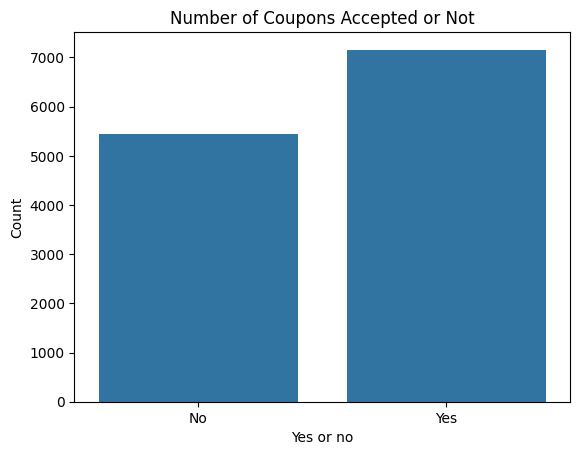

In [103]:
#bar plot of yes/no
sns.countplot(data, x='Y')
plt.title('Number of Coupons Accepted or Not')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Yes or no')
plt.ylabel('Count')



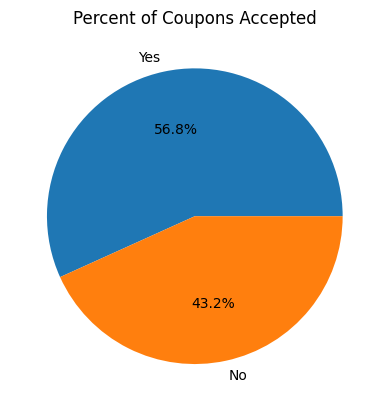

In [105]:
#Show acceptance rate as a percentage
plt.pie(data['Y'].value_counts(), labels=['Yes', 'No'], autopct='%1.1f%%')
plt.title('Percent of Coupons Accepted')
plt.show()

6. Use a histogram to visualize the temperature column.

temperature
80    6475
55    3830
30    2305
Name: count, dtype: int64


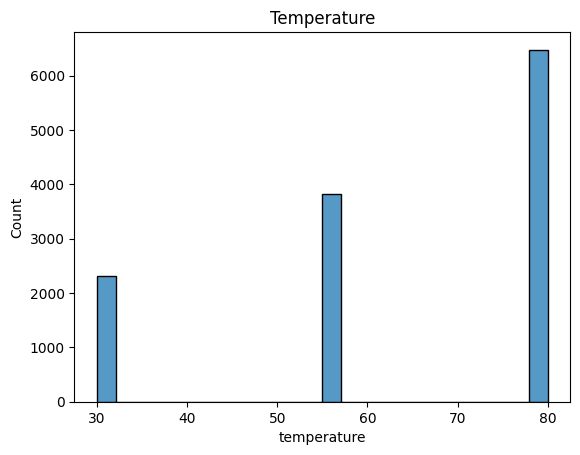

In [106]:
print(data['temperature'].value_counts())
sns.histplot(data['temperature'])
plt.title('Temperature')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [107]:
df_bar = data[data['coupon'] =="Bar"]

2. What proportion of bar coupons were accepted?


In [108]:
#print(df_bar['Y'].value_counts())
bar_coupons_accepted = round((df_bar['Y'].sum()/len(df_bar)) * 100,2)
print(f'Percent of bar coupons accepted {bar_coupons_accepted}%')

Percent of bar coupons accepted 41.0%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [109]:
#data frame of those who went less than 3 times
df_bar_less_3 = df_bar[df_bar['Bar'].isin(['never', 'less1','1~3'])]

#Find the Rate
accept_rate_bar_less_3 = round((df_bar_less_3['Y'].sum()/len(df_bar_less_3)*100),2)
print(f'Acceptance rate for those who went to a bar 3 or fewer times a month: {accept_rate_bar_less_3}%')

#data frame of those who went more than 3 times
df_bar_more_3 = df_bar[df_bar['Bar'].isin(['4~8', 'gt8'])]

#Find the Rate
accept_rate_bar_more_3 = round((df_bar_more_3['Y'].sum()/len(df_bar_more_3)*100),2)
print(f'Acceptance rate for those who went to a bar more than 3 times a month: {accept_rate_bar_more_3}%')

Acceptance rate for those who went to a bar 3 or fewer times a month: 37.05%
Acceptance rate for those who went to a bar more than 3 times a month: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [110]:

#data frame of those who went more than 1 times
df_bar_more1 = df_bar[df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])]

#data frame of those who are over 25
df_bar_over_25 = df_bar_more1[df_bar_more1['age']>25]

#Find the rate for over 25 and more than 1 a month
accept_rate_bar_over_25 = round((df_bar_over_25['Y'].sum()/len(df_bar_over_25)*100),2)
print(f'Acceptance rate for those who went to bar more than once and are over 25: {accept_rate_bar_over_25}%')

#data frame for all others
df_bar_all_others = df_bar[~((df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])) & (df_bar['age'] > 25))]

#Find the Rate
accept_rate_all_others = round((df_bar_all_others['Y'].sum()/len(df_bar_all_others)*100),2)
print(f'Acceptance rate for all others: {accept_rate_all_others}%')

Acceptance rate for those who went to bar more than once and are over 25: 69.52%
Acceptance rate for all others: 33.46%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [111]:
#find more than 1 and with passengers and not farming, fishing, or forestry
df_bar_more1_passengers = df_bar[((df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])) & (df_bar['passanger'].isin(['Alone','Friend(s)','Partner'])) & (~df_bar['occupation'].isin(['Farming Fishing & Forestry'])))]

#Find the rate for more than 1 and with passengers
accept_rate_bar_more1_passengers = round((df_bar_more1_passengers['Y'].sum()/len(df_bar_more1_passengers)*100),2)
print(f'Acceptance rate for those who went to more than once and no kids as passengers and not in the occupation of farming, fishing, or forestry: {accept_rate_bar_more1_passengers}%')

#find the opposite of more than 1 and with passengers and not farming, fishing, or forestry
df_bar_opposite_more1_passengers = df_bar[~((df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])) & (df_bar['passanger'].isin(['Alone','Friend(s)','Partner'])) & (~df_bar['occupation'].isin(['Farming Fishing & Forestry'])))]

#Find the rate for more than 1 and with passengers
accept_rate_bar_opposite_more1_passengers = round((df_bar_opposite_more1_passengers['Y'].sum()/len(df_bar_opposite_more1_passengers)*100),2)
print(f'Acceptance rate for the OPPOSITE those who went to more than once and no kids as passengers and not in the occupation of farming, fishing, or forestry: {accept_rate_bar_opposite_more1_passengers}%')



Acceptance rate for those who went to more than once and no kids as passengers and not in the occupation of farming, fishing, or forestry: 71.32%
Acceptance rate for the OPPOSITE those who went to more than once and no kids as passengers and not in the occupation of farming, fishing, or forestry: 29.54%


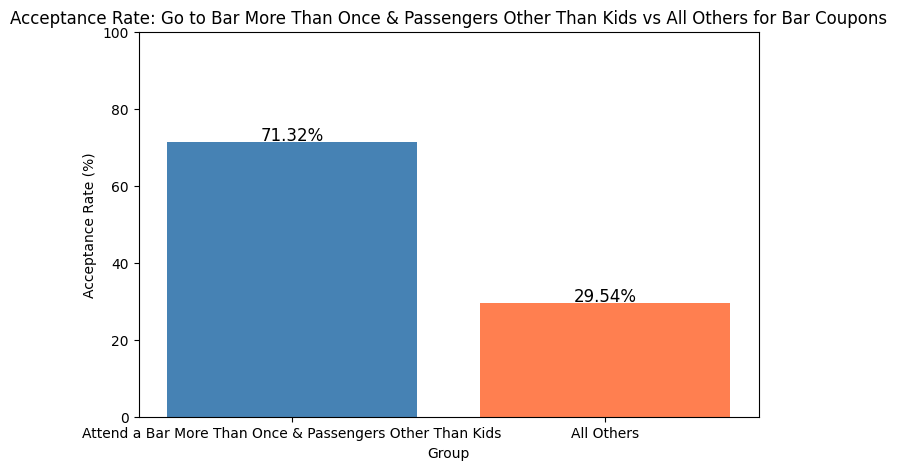

In [113]:
#Create a bar chart

#acceptance rates and labels
labels = ['Attend a Bar More Than Once & Passengers Other Than Kids', 'All Others']
rates = [accept_rate_bar_more1_passengers, accept_rate_bar_opposite_more1_passengers]

#bar chart
plt.figure(figsize=(8, 5))
plt.bar(labels, rates, color=['steelblue', 'coral'])

#Percentages as labels
for i, rate in enumerate(rates):
    plt.text(i, rate + 0.5, f'{rate}%', ha='center', fontsize=12)

# Labels and title
plt.title('Acceptance Rate: Go to Bar More Than Once & Passengers Other Than Kids vs All Others for Bar Coupons')
plt.xlabel('Group')
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 100)  # Keep y axis from 0 to 100 since its a percentage
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [114]:
#df go to bars more than once a month and are under the age of 30
df_bar_more1_under30 = df_bar[((df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &  (df_bar['age'] < 30))]


#Find the rate for go to bars more than once a month and are under the age of 30
accept_rate_bar_more1_under30 = round((df_bar_more1_under30['Y'].sum()/len(df_bar_more1_under30)*100),2)
print(f'Acceptance rate for those who went to more than once and are under 30: {accept_rate_bar_more1_under30}%')

#find the opposite of go to bars more than once a month and are under the age of 30
df_bar_opposite_more1_under30 = df_bar[~((df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &  (df_bar['age'] < 30))]

#Find the rate for more than 1 and with passengers
accept_rate_bar_opposite_more1_under30 = round((df_bar_opposite_more1_under30['Y'].sum()/len(df_bar_opposite_more1_under30)*100),2)
print(f'Acceptance rate for the OPPOSITE those who went to more than once and are under 30: {accept_rate_bar_opposite_more1_under30}%')



Acceptance rate for those who went to more than once and are under 30: 72.17%
Acceptance rate for the OPPOSITE those who went to more than once and are under 30: 34.53%


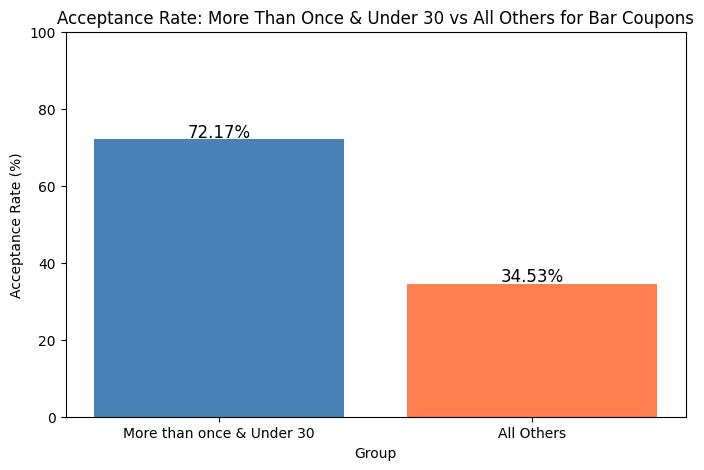

In [115]:
#Create a bar chart

#acceptance rates and labels
labels = ['More than once & Under 30', 'All Others']
rates = [accept_rate_bar_more1_under30, accept_rate_bar_opposite_more1_under30]

#bar chart
plt.figure(figsize=(8, 5))
plt.bar(labels, rates, color=['steelblue', 'coral'])

#Percentages as labels
for i, rate in enumerate(rates):
    plt.text(i, rate + 0.5, f'{rate}%', ha='center', fontsize=12)

# Labels and title
plt.title('Acceptance Rate: More Than Once & Under 30 vs All Others for Bar Coupons')
plt.xlabel('Group')
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 100)  # Keep y axis from 0 to 100 since its a percentage
plt.show()

# 7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?


*   Drivers who received bar coupons had an overall acceptance rate of **40%**.
*   Drivers who went to a bar 3 or fewer times a month had an acceptance rate of 37.05% compared to those who went to a bar more than 3 times a month at **76.88%**.
*   Drivers who went to the bar more than once and are over 25 had an acceptance rate **69.52%** compared to all others at 33.46%.
*   Drivers who went to more than once and had no kids as passengers and were not in the occupation of farming, fishing, or forestry had an acceptance rate of **71.32%** compared to all others at 29.54%.
*   **Overall:** Drivers who attend the bars more than once are more likely to accept the bar coupons.  Those that attended a bar more than once had an acceptance rate around **70%** regardless of other factors such as age, passengers, job.

## Actionable Items
*   Target drivers with 1 or more visits per month and who are 25 and older
*   Do not focus on drivers who have kids in the car

## Next Steps
*   Take a look at income levels to determine if there are any trends in income and acceptance
*   Take a look at driving direction to see if the direction of the bar matters






### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

# Q: What proportion of coffee coupons were accepted?

In [21]:
df_coffee = data[data['coupon'] =='Coffee House']
accept_rate_coffee = round((df_coffee['Y'].sum()/len(df_coffee)*100),2)
print(f'Acceptance rate for ALL coffee coupons: {accept_rate_coffee}%')
print('##')

#Acceptance Rate based on Category
coffee_acceptance = df_coffee.groupby('CoffeeHouse')['Y'].mean() * 100
print(f'The acceptance rate for each category:\n {coffee_acceptance.round(2)}')

Acceptance rate for ALL coffee coupons: 49.86%
##
The acceptance rate for each category:
 CoffeeHouse
1~3      64.74
4~8      68.59
gt8      65.79
less1    48.04
never    20.82
Name: Y, dtype: float64


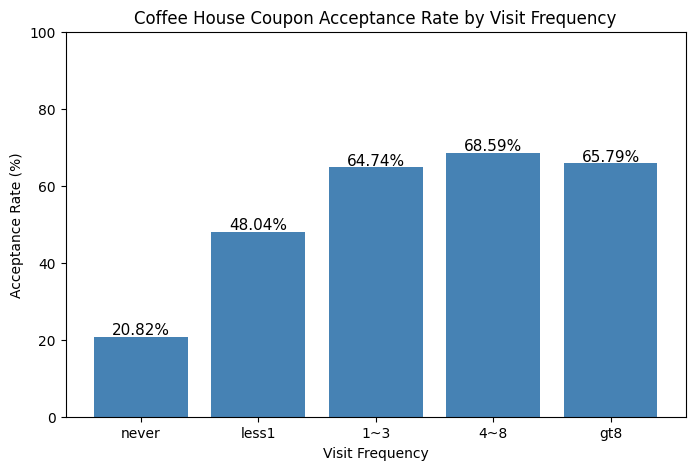

In [116]:
coffee_acceptance = df_coffee.groupby('CoffeeHouse')['Y'].mean() * 100

# Define the order of the bars from least to most visits
order = ['never', 'less1', '1~3', '4~8', 'gt8']
coffee_acceptance = coffee_acceptance.reindex(order)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(order, coffee_acceptance, color='steelblue')

# Add percentage on top of each bar
for i, rate in enumerate(coffee_acceptance):
    plt.text(i, rate + 0.5, f'{rate:.2f}%', ha='center', fontsize=11)

plt.title('Coffee House Coupon Acceptance Rate by Visit Frequency')
plt.xlabel('Visit Frequency')
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 100)
plt.show()

# Compare the acceptance rate between those who went to a coffe *house* 3 or fewer times a month to those who went more.


In [117]:
df_coffee['CoffeeHouse'].value_counts()

#df go to coffee house 3 or fewer
df_coffee_less3 = df_coffee[df_coffee['CoffeeHouse'].isin(['1~3', 'less1', 'never'])]

#Find the rate for go to coffeehouse 3 or less
accept_rate_coffee_less3 = round((df_coffee_less3['Y'].sum()/len(df_coffee_less3)*100),2)
print(f'Acceptance rate for those who went to Coffee House 3 or less: {accept_rate_coffee_less3}%')

#df go to OPPPOSITE coffee house 3 or fewer
df_opposite_coffee_less3 = df_coffee[~df_coffee['CoffeeHouse'].isin(['1~3', 'less1', 'never'])]

#Find the rate for OPPPOSITE coffee house 3 or fewer
accept_rate_opposite_coffee_less3 = round((df_opposite_coffee_less3['Y'].sum()/len(df_opposite_coffee_less3)*100),2)
print(f'Acceptance rate for the went to Coffee House more than 3 times: {accept_rate_opposite_coffee_less3}%')



Acceptance rate for those who went to Coffee House 3 or less: 44.87%
Acceptance rate for the went to Coffee House more than 3 times: 67.5%


# Compare the acceptance rate between those who single, widowed, divorced and those who are not.

In [118]:


#df based on single
df_coffee_single = df_coffee[df_coffee['maritalStatus'].isin(['Single', 'Divorced', 'Widowed'])]

#Find the rate for go to coffeehouse 3 or less
accept_rate_coffee_single = round((df_coffee_single['Y'].sum()/len(df_coffee_single)*100),2)
print(f'Acceptance rate for Coffee House for single, divorced, widowed: {accept_rate_coffee_single}%')

#df go to OPPPOSITE coffee house 3 or fewer
df_opposite_coffee_single = df_coffee[~df_coffee['maritalStatus'].isin(['Single', 'Divorced', 'Widowed'])]

#Find the rate for OPPPOSITE coffee house 3 or fewer
accept_rate_opposite_coffee_single = round((df_opposite_coffee_single['Y'].sum()/len(df_opposite_coffee_single)*100),2)
print(f'Acceptance rate for Coffee coupons for marriend or partnered: {accept_rate_opposite_coffee_single}%')



Acceptance rate for Coffee House for single, divorced, widowed: 51.32%
Acceptance rate for Coffee coupons for marriend or partnered: 48.73%


# Compare the acceptance rate between those who went to a coffe *house* 1 or more times a month to those who went less.


In [119]:

#df go to coffee house 1 or more
df_coffee_more1 = df_coffee[df_coffee['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])]

#Find the rate for go to coffeehouse 3 or less
accept_rate_coffee_more1 = round((df_coffee_more1['Y'].sum()/len(df_coffee_more1)*100),2)
print(f'Acceptance rate for those who went to Coffee House 1 or more: {accept_rate_coffee_more1}%')

#df go to OPPPOSITE coffee house 3 or fewer
df_opposite_coffee_more1 = df_coffee[~df_coffee['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])]

#Find the rate for OPPPOSITE coffee house 3 or fewer
accept_rate_opposite_coffee_more1 = round((df_opposite_coffee_more1['Y'].sum()/len(df_opposite_coffee_more1)*100),2)
print(f'Acceptance rate for the went to Coffee House more than 3 times: {accept_rate_opposite_coffee_more1}%')



Acceptance rate for those who went to Coffee House 1 or more: 66.01%
Acceptance rate for the went to Coffee House more than 3 times: 34.91%


# Compare the acceptance rate by time of day for customers who attend 1 or more times

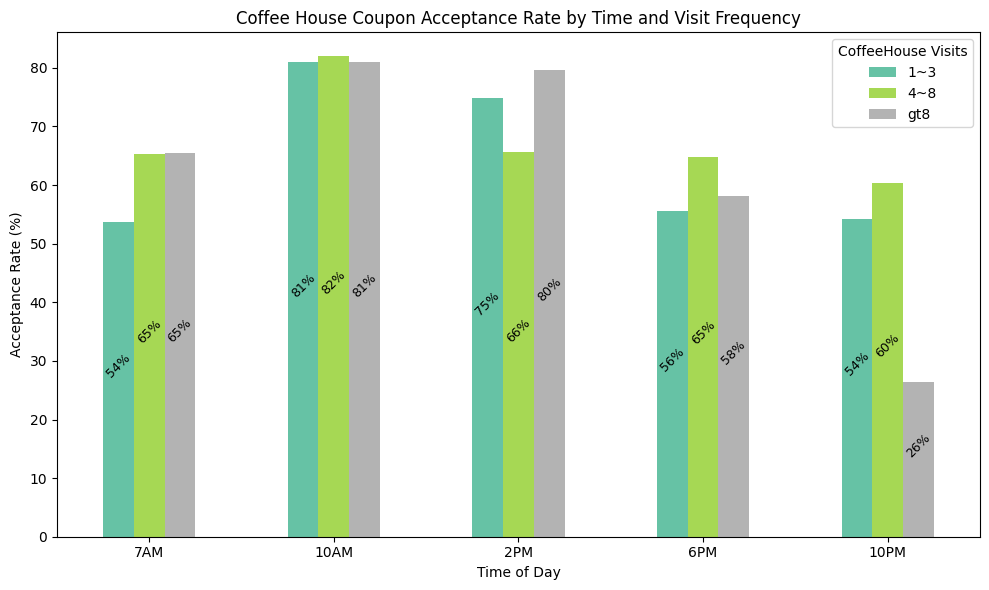

In [120]:

# Group by both time AND CoffeeHouse to get acceptance rate for each combination
df_coffee_segmented = df_coffee_more1.groupby(['time', 'CoffeeHouse'])['Y'].mean() * 100

# Unstack turns the CoffeeHouse categories into separate columns (segments)
df_coffee_segmented = df_coffee_segmented.unstack()

# Reorder the time axis
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
df_coffee_segmented = df_coffee_segmented.reindex(time_order)

# Reorder the CoffeeHouse segments
coffee_order = ['1~3', '4~8', 'gt8']
df_coffee_segmented = df_coffee_segmented[coffee_order]

# Plot
ax = df_coffee_segmented.plot(kind='bar', figsize=(10, 6), colormap='Set2')

# Add percentage labels on each segment
for container in ax.containers:
    ax.bar_label(container, fmt='%0.f%%', label_type='center', fontsize=9, padding = 10, rotation =45)

plt.title('Coffee House Coupon Acceptance Rate by Time and Visit Frequency')
plt.xlabel('Time of Day')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='CoffeeHouse Visits')
plt.tight_layout()
plt.show()

In [121]:
#df go to coffee house weather
df_coffee_weather = df_coffee[(df_coffee['weather'].isin(['Snowy', 'Rainy'])) & (df_coffee['time'].isin(['7AM', '10AM'])) ]

#Find the rate for go to coffeehouse 3 or less
accept_rate_coffee_weather = round((df_coffee_weather['Y'].sum()/len(df_coffee_weather)*100),2)
print(f'Acceptance rate for weather snowy or rainy and 7am or 10am: {accept_rate_coffee_weather}%')

#df go to OPPPOSITE coffee house rainy, snow
df_opposite_coffee_weather = df_coffee[~(df_coffee['weather'].isin(['Snowy', 'Rainy'])) & (df_coffee['time'].isin(['7AM', '10AM'])) ]

#Find the rate for OPPPOSITE coffee house 3 or fewer
accept_rate_opposite_coffee_weather = round((df_opposite_coffee_weather['Y'].sum()/len(df_opposite_coffee_weather)*100),2)
print(f'Acceptance rate for all others: {accept_rate_opposite_coffee_more1}%')




Acceptance rate for weather snowy or rainy and 7am or 10am: 69.66%
Acceptance rate for all others: 34.91%


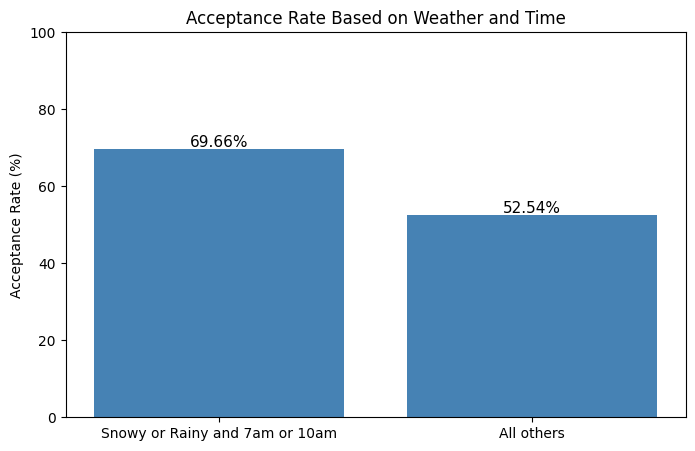

In [122]:

# Define the order of the bars from least to most visits
x_order = ['Snowy or Rainy and 7am or 10am', 'All others']
y_rate = [accept_rate_coffee_weather, accept_rate_opposite_coffee_weather ]


# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(x = x_order, height = y_rate ,color='steelblue')

# Add percentage on top of each bar
for i, rate in enumerate(y_rate):
    plt.text(i, rate + 0.5, f'{rate:.2f}%', ha='center', fontsize=11)

plt.title('Acceptance Rate Based on Weather and Time')
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 100)
plt.show()

In [125]:
# Group by both time AND CoffeeHouse to get acceptance rate for each combination

df_coffee_segmented = df_coffee.groupby(['time', 'gender'])['Y'].mean() * 100
print('Accpetance Rate by Time and Gender')
print(df_coffee_segmented.unstack())

print('-------------------------------')

df_coffee_segmented = df_coffee.groupby(['gender'])['Y'].mean() * 100
print('Accpetance Rate by Gender')
print(df_coffee_segmented)

print('-------------------------------')

df_coffee_segmented = df_coffee.groupby(['time', 'weather', 'gender'])['Y'].mean() * 100
print('Accpetance Rate by Time, Weather, Gender')
print(df_coffee_segmented.unstack())




Accpetance Rate by Time and Gender
gender     Female       Male
time                        
10AM    64.835165  63.205418
10PM    38.255034  46.621622
2PM     56.585366  52.741514
6PM     39.272727  42.936803
7AM     42.768595  46.620047
-------------------------------
Accpetance Rate by Gender
gender
Female    49.169922
Male      50.592478
Name: Y, dtype: float64
-------------------------------
Accpetance Rate by Time, Weather, Gender
gender           Female       Male
time weather                      
10AM Rainy    64.583333  71.111111
     Sunny    64.864865  62.311558
10PM Rainy    30.188679  43.636364
     Snowy    13.636364  21.951220
     Sunny    67.307692  69.230769
2PM  Snowy    50.000000  45.000000
     Sunny    56.783920  53.168044
6PM  Rainy    64.285714  54.545455
     Snowy    40.000000  40.000000
     Sunny    38.492872  43.008475
7AM  Snowy    77.272727  65.853659
     Sunny    39.318182  44.587629


# Hypothsis about CoffeeHouse Coupon


*   Drivers who attend a coffee house 1 or more times have an acceptance rate of **66%.**
*   Drivers who attend a coffee house 1 or more times and have a time of 10am have an acceptance rate of over **80%**.
*   Drivers with times at 10am (**80%**) and 2pm(**73%**) have the highest accpetance rates.
*   No difference in acceptance rate between drivers who are single and those with a partner/significant other.  Both around **50%**.
*   No difference in acceptance rates between drivers who are male and those who are female.  Both with a rate of approximately **50%**.
*   No major differences in acceptance rates across various times of day between male and female drivers. Both groups peaked at 10 AM with a rate of approximately **63%**.
*   Drivers with weather of snowy and a time 7am had an accpetance rate of **71%** compared to sunny and a time of 7am compared at 41%.
*   Drivers with weather of snowy or rainy and a time 7am or 10am had an accpetance rate of **69%** compared to all others at 52%.

*   **Overall:** Drivers who attend a coffee house more than once, travel in the mornings between 7am and 10am are mor likely to accept coupons.  Additionally poor weather in the morning tends to lend itself to a higher acceptance rate.

## Actionable Items

*   Target times between 7am and 10am
*   Target days with rainy and snowy especially in the mornings
*   Target drivers with 1 or more visits per month
*   Do not focus on gender or relationship status

## Next Steps

*   Take note if weather continues to play a role in acceptance
*   Look for trends for drivers with 1 or less to try and increase their acceptance












